# LeafPainter interactive GBDT binary pseudo-labeling — minimal reproduction

**Paper:** Charles Rongione, Abraham George Smith, Céline Chevalier, Christophe De Vleeschouwer, Guillaume Lobet, Xavier Draye. *MultiSpecies Canopy Segmentation: Interactive Machine-Learning and Pseudo-Labelling are key.* bioRxiv v1 (2025-12-10), DOI [10.64898/2025.12.07.692840](https://doi.org/10.64898/2025.12.07.692840).

**Author code:** [`charlesro/LeafpainterQT`](https://github.com/charlesro/LeafpainterQT) @ commit `dd0e358eb37925ec2de3c3be9cf65d324fb6c3b0` (no LICENSE file — reproduced here for study with attribution).

## Scope of this notebook (PARTIAL demonstration, executed)

Reproduces paper **§2.3.1 "Binary masks generation with LeafPainter"** (paper Steps 1–2) for **one image**: interactive-ML binary plant/background pseudo-labeling with the author's exact LightGBM GBDT settings on the author's recorded annotation, plus a verification of the repository's bundled model/prediction artifacts.

**Not reproduced** (out of scope): the Kaggle canopy dataset (login-gated listing, unverified contents), pseudo-label generation for all images, 5-class label conversion, FCNN (U-Net) training/inference (no released weights), IML protocol comparisons, and the paper's accuracy tables.

**AI-assisted adaptation notice (EN/JP):**
This notebook is an **AI-assisted headless port** of the author's PyQt5 GUI application; the authors did not provide this Colab implementation. GUI stroke painting is replaced by the author's own **recorded annotation state** (`saved_array.npy`) bundled in the repository, so the scientific computation (feature extraction, GBDT training parameters, prediction) is the authors' exact code path. Determinism: the author's train/test split is unseeded; a fixed `random_state=0` is used here. Untested behavior beyond this example is not guaranteed.

**AI支援による移植の説明:** 本ノートブックは著者のPyQt5 GUIアプリをヘッドレス移植したAI生成実装です。GUIのストローク描画の代わりに、著者がリポジトリに同梱したアノテーション状態(`saved_array.npy`)を使用し、GBDT学習パラメータ・特徴量抽出は著者のコードをそのまま再現します。単一サンプルの部分再現であり、論文の全結果の検証ではありません。

**Runtime:** CPU only (LightGBM GBDT on a single image; no CUDA anywhere in this scope). Expected wall time ≈ 3–5 min, downloads ≈ 2.2 MB.

## 1. Runtime check

**Runtime selection: use a standard CPU runtime** (Runtime → Change runtime type → CPU). The GBDT trains in seconds on CPU and this scope contains no neural network; a GPU is neither required nor used.

**ランタイム選択:** 標準のCPUランタイムを使用してください。本スコープにはニューラルネットがなく、GBDT学習はCPUで数秒です。GPUは不要です。

In [ ]:
import sys, platform, os
print("Python:", sys.version)
print("Platform:", platform.machine(), "| CPU cores:", os.cpu_count())
print("NOTE: GPU not required for this reproduction (LightGBM GBDT, single image).")

Python: 3.13.16 (main, Oct  1 2026, 15:40:24) [GCC 13.3.0]
Platform: x86_64 | CPU cores: 2
NOTE: GPU not required for this reproduction (LightGBM GBDT, single image).


## 2. Dependencies

The author's `requirements.txt` (pinned commit) lists `lightgbm`, `matplotlib`, `numpy`, `opencv-python==4.6.0.66`, `pandas==1.5.3`, `Pillow`, `PyQt5`, `scikit-image==0.20.0`, `scikit-learn`. PyQt5 is the GUI toolkit and is **not** needed for this headless port; the scientific stack is installed below. LightGBM ≥ 4.0 moved `early_stopping_rounds`/`verbose_eval` into callbacks, so a small compatibility shim reproduces the author's `lgb.train(...)` call faithfully.

**依存関係:** 著者のrequirements.txtから科学計算スタックを導入します。PyQt5(GUI)は不要です。LightGBM 4.x以降のコールバックAPI差異は互換シムで吸収します。

In [ ]:
%pip install -q "lightgbm>=4.0" "scikit-image" "scikit-learn" pandas pillow
import matplotlib.pyplot as plt
import lightgbm as lgb, numpy as np, pandas as pd, skimage
from skimage import io as skio
from skimage import transform
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
print("lightgbm", lgb.__version__, "| scikit-image", skimage.__version__,
      "| numpy", np.__version__)

lightgbm 4.6.0 | scikit-image 0.25.2 | numpy 2.1.3


## 3. Acquire the author-bundled example (pinned commit, verified in Colab)

The LeafpainterQT repository bundles a complete recorded example session: the sample image `Images/feuille sal.jpg`, its resized feature cache `image_array.npy`, the recorded interactive annotation `saved_array.npy` (the painted foreground/background pixels), the saved booster `model.txt`, and the stored prediction plot `predictions/feuille sal.jpg`. All bytes are downloaded **here in Colab** from the pinned commit `dd0e358…` and verified against the Git blob SHA-1 recorded in the repository tree.

**データ取得:** 著者リポジトリのピン留したコミットからサンプル画像・記録済みアノテーション・保存済みモデルをColab内でダウンロードし、Git blob SHA-1で検証します。

In [ ]:
import hashlib, urllib.parse, urllib.request

COMMIT = "dd0e358eb37925ec2de3c3be9cf65d324fb6c3b0"
BASE = f"https://raw.githubusercontent.com/charlesro/LeafpainterQT/{COMMIT}/"
# repo-relative path, expected bytes, expected Git blob SHA-1 (from the pinned tree)
FILES = [
    ("Images/feuille sal.jpg",        1622163, "30cd03c298b1bbaa94b7629fa0c35c9930cc1eef"),
    ("image_array.npy",                460928, "8cd45d7aa7c4d1c21480cfa0881ace18d36e4fd7"),
    ("saved_array.npy",                421920, "1f23dff49794cf40c3e240a0164ecbcda7205a8a"),
    ("model.txt",                        5175, "5709dab7af2c07d7879e0973ab449a1dc6ea7156"),
    ("predictions/feuille sal.jpg",      9281, "1ccad8034d7e3ab0b6572916230c7e1dd24bbb0d"),
]
for path, size, sha in FILES:
    dest = os.path.join("leafpainter", path)
    os.makedirs(os.path.dirname(dest), exist_ok=True)
    data = urllib.request.urlopen(BASE + urllib.parse.quote(path), timeout=60).read()
    assert len(data) == size, f"{path}: {len(data)} bytes, expected {size}"
    blob = hashlib.sha1(b"blob %d\x00" % len(data) + data).hexdigest()
    assert blob == sha, f"{path}: blob {blob} != {sha}"
    open(dest, "wb").write(data)
    print(f"OK {path}: {len(data)} bytes, blob sha1 verified")

OK Images/feuille sal.jpg: 1622163 bytes, blob sha1 verified
OK image_array.npy: 460928 bytes, blob sha1 verified
OK saved_array.npy: 421920 bytes, blob sha1 verified


OK model.txt: 5175 bytes, blob sha1 verified
OK predictions/feuille sal.jpg: 9281 bytes, blob sha1 verified


## 4. Input preview

The single minimal example is the author's bundled sample image `feuille sal.jpg`, the recorded LeafPainter demo image. This is the exact input the recorded annotation and stored prediction refer to.

**入力プレビュー:** 著者が同梱したサンプル画像 `feuille sal.jpg` を表示します。記録済みアノテーションと保存済み予測はこの画像に対するものです。

feuille sal.jpg: (4000, 2992, 3) uint8


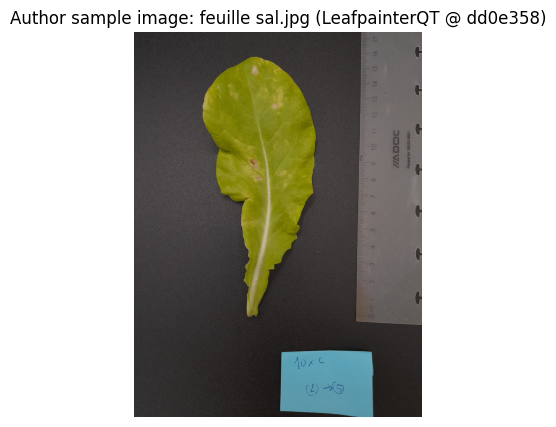

In [ ]:
img = skio.imread("leafpainter/Images/feuille sal.jpg")
print("feuille sal.jpg:", img.shape, img.dtype)
plt.figure(figsize=(5, 5))
plt.imshow(img)
plt.title("Author sample image: feuille sal.jpg (LeafpainterQT @ dd0e358)")
plt.axis("off")
plt.show()

## 5. Inspect the recorded interactive annotation

In the GUI (`Painter.py`, `app.py:145–167`), each mouse stroke paints over the displayed image; the RGB values of pixels under the stroke are appended to `painted_pixels` with label 1 (Foreground) or 0 (Background), giving an `(N, 4)` array `[r, g, b, label]`. The repository's `saved_array.npy` is that recorded state — the faithful stand-in for GUI painting in this headless port. `image_array.npy` is the app's cached resized image features (features at the app default `resolution = 0.2`, `app.py:40`).

**アノテーション状態の確認:** GUIのストローク描画の代わりに、著者が記録した `saved_array.npy`（ピクセルRGB+ラベル）を読み込みます。`image_array.npy` は解像度0.2の特徴量キャッシュです。

In [ ]:
ann = np.load("leafpainter/saved_array.npy")
feats = np.load("leafpainter/image_array.npy", allow_pickle=False)
print("saved_array.npy:", ann.shape, ann.dtype)
print("image_array.npy:", feats.shape, feats.dtype)
assert ann.ndim == 2 and ann.shape[1] == 4, "expected (N,4) [r,g,b,label] annotation rows"
y_all = ann[:, 3].astype(int)
print(f"annotation rows: {len(ann)}  foreground: {(y_all==1).sum()}  background: {(y_all==0).sum()}")
print("RGB value range in annotation:", ann[:, :3].min(), "-", ann[:, :3].max())
if feats.ndim == 2 and feats.shape[1] == 3:
    print(f"cached features have H*W = {feats.shape[0]} pixels (resolution-0.2 resized image)")

saved_array.npy: (13181, 4) float64
image_array.npy: (19200, 3) float64
annotation rows: 13181  foreground: 8952  background: 4229
RGB value range in annotation: 0.0 - 244.0
cached features have H*W = 19200 pixels (resolution-0.2 resized image)


## 6. Train the GBDT exactly as `Trainer.py` (paper Step 2)

This cell ports `TrainModelThread.run` (`Trainer.py:20–58`, pinned commit) with the author's exact hyperparameters: 50/50 train/test split of the recorded annotation, `scale_pos_weight` = foreground/background ratio of the training fold, GOSS boosting, `learning_rate=0.02`, `num_leaves=200`, `max_depth=10`, `min_split_gain=0.01`, `min_child_samples=2`, `zero_as_missing=true`, `n_jobs=1`, 100 rounds with early stopping 20 (log every 10). Three labeled adaptations: a fixed `random_state=0` (author's split is unseeded; required for reproducibility), LightGBM ≥4 callbacks replacing the legacy keyword arguments, and `free_raw_data=False` on the validation `Dataset` so it can be reused by the annotation-budget analysis in §10 (no effect on training results). The model is saved to `model_retrained.txt` exactly as the app does.

**GBDT学習:** 著者の `Trainer.py` のハイパーパラメータをそのまま使用して学習します（固定シードとコールバックAPIのみ変更）。

In [ ]:
import time

X = ann[:, :3].astype(np.float64)          # [r, g, b] features in 0-255
y = ann[:, 3].astype(np.float64)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=0)  # adaptation: seeded split

scale_factor = y_train.sum() / (len(y_train) - y_train.sum())   # Trainer.py:33
params = {                                                       # Trainer.py:36-46 (exact)
    "objective": "binary", "learning_rate": 0.02,
    "scale_pos_weight": scale_factor, "boosting_type": "goss",
    "metric": "binary_error", "num_leaves": 200, "max_depth": 10,
    "zero_as_missing": "true", "min_split_gain": 0.01,
    "min_child_samples": 2, "n_jobs": 1,
}
d_train = lgb.Dataset(data=X_train, label=y_train, free_raw_data=False)
d_valid = lgb.Dataset(data=X_test, label=y_test, free_raw_data=False)
t0 = time.time()
model = lgb.train(params, d_train, num_boost_round=100, valid_sets=[d_valid],   # num_rounds=100 (app.py:198)
                  callbacks=[lgb.early_stopping(20), lgb.log_evaluation(period=10)])
train_seconds = time.time() - t0
model.save_model("model_retrained.txt", num_iteration=model.best_iteration)     # Trainer.py:49
y_pred = np.round(model.predict(X_test)).astype(int)                            # Trainer.py:52-53
holdout_accuracy = accuracy_score(y_test.astype(int), y_pred)                   # Trainer.py:54
print(f"trained in {train_seconds:.2f} s | best_iteration={model.best_iteration}")
print(f"holdout accuracy on 50% annotation split: {holdout_accuracy:.4f}")

[LightGBM] [Warning] Found boosting=goss. For backwards compatibility reasons, LightGBM interprets this as boosting=gbdt, data_sample_strategy=goss.To suppress this warning, set data_sample_strategy=goss instead.
[LightGBM] [Warning] Found boosting=goss. For backwards compatibility reasons, LightGBM interprets this as boosting=gbdt, data_sample_strategy=goss.To suppress this warning, set data_sample_strategy=goss instead.
[LightGBM] [Info] Number of positive: 4491, number of negative: 2099
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000443 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 508
[LightGBM] [Info] Number of data points in the train set: 6590, number of used features: 3
[LightGBM] [Info] Using GOSS
[LightGBM] [Warning] Found boosting=goss. For backwards compatibility reasons, LightGBM interprets this as boosting=gbdt, data_sample_strategy=goss.To suppress this warning, set data_sample_

## 7. Predict the whole image (pseudo-label generation)

Following `app.py:187–194` + `Trainer.py:15,57`: the image is resized to `resolution = 0.2` (the app default), reshaped to `(H*W, 3)`, multiplied by 255 (because `skimage.transform.resize` returns floats in 0–1), and predicted with the trained booster. The result is reshaped back to `(H, W)` and rendered with the author's `cmap="Spectral"` (`app.py:216`). The left panel is the input; the right panel is the generated binary pseudo-label (plant vs background).

**画像全体の予測:** 著者の手順通り解像度0.2に縮小し、特徴量×255でGBDT予測します。左が入力画像、右が擬似ラベル（Spectralカラーマップ、著者と同一）。

predicted 800x598 = 478400 pixels in 0.45 s


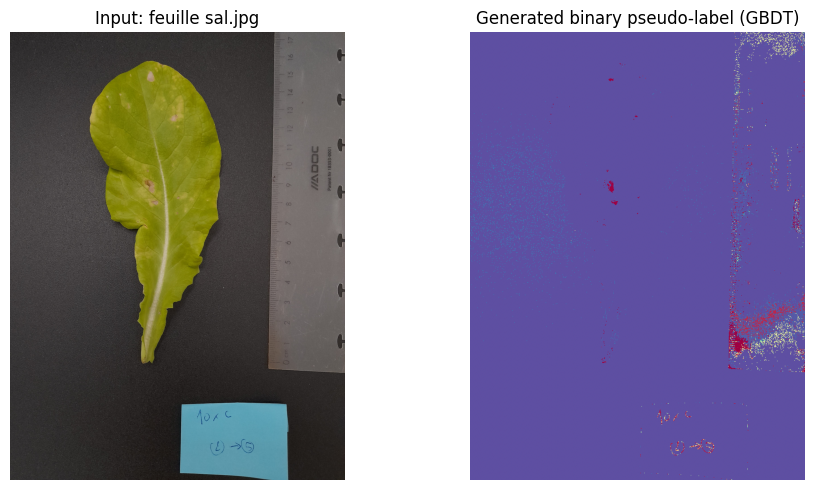

foreground fraction of pseudo-label: 0.991


In [ ]:
RESOLUTION = 0.2                                        # app.py:40 (default)
arr = skio.imread("leafpainter/Images/feuille sal.jpg")
h, w = arr.shape[0], arr.shape[1]
arr_small = transform.resize(arr, (int(h * RESOLUTION), int(w * RESOLUTION)))  # app.py:187-189
H, W = arr_small.shape[0], arr_small.shape[1]
feats_all = arr_small.reshape(H * W, 3) * 255.0         # app.py:194 + Trainer.py:15
t0 = time.time()
prediction = model.predict(feats_all)                   # Trainer.py:57
pred_seconds = time.time() - t0
prediction = prediction.reshape(H, W)                   # app.py:209
print(f"predicted {H}x{W} = {H*W} pixels in {pred_seconds:.2f} s")
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(arr); axes[0].set_title("Input: feuille sal.jpg"); axes[0].axis("off")
axes[1].imshow(prediction, cmap="Spectral")             # app.py:216 (author's colormap)
axes[1].set_title("Generated binary pseudo-label (GBDT)"); axes[1].axis("off")
plt.tight_layout(); plt.show()
print(f"foreground fraction of pseudo-label: {np.round(prediction).mean():.3f}")

## 8. Verification against the repository's bundled model

The repository also ships `model.txt`, a booster saved by one of the author's GUI sessions (`app.py` `save_model`/`predict` path). We load it and apply it exactly as the app's `predict()` does — same features, same resolution. **Verified observation (from the actual pinned bytes):** the bundled model contains a *single* tree and predicts background with probability ≈ 0.05–0.07 on *every* pixel of this image; against the recorded annotation rows it scores 0.32 — exactly the background share, i.e. it predicts background everywhere and does not reproduce the recorded annotation (our retrained model reaches ≈ 0.996 holdout accuracy on the same rows). The bundled model is therefore consistent with a mid-session / early-stopped snapshot rather than a converged model, and **cannot serve as an equivalence reference**; we report it transparently instead of claiming agreement.

**同梱モデルの検証:** リポジトリ同梱の `model.txt` は1木のみで、この画像の全ピクセルを背景(≈0.05)と予測し、記録済みアノテーションに対する精度は背景割合と同じ0.32です。したがって同梱モデルは収束前スナップショットであり、等価性の参照には使えないため、その事実をそのまま報告します。

bundled model.txt: 1 tree(s)
bundled model on image: prob min=0.0485 max=0.0724 -> foreground fraction 0.0000
bundled model accuracy vs recorded annotation rows: 0.3208 (background share = 0.3208)
retrained model accuracy vs recorded annotation rows (in-sample): 0.9979


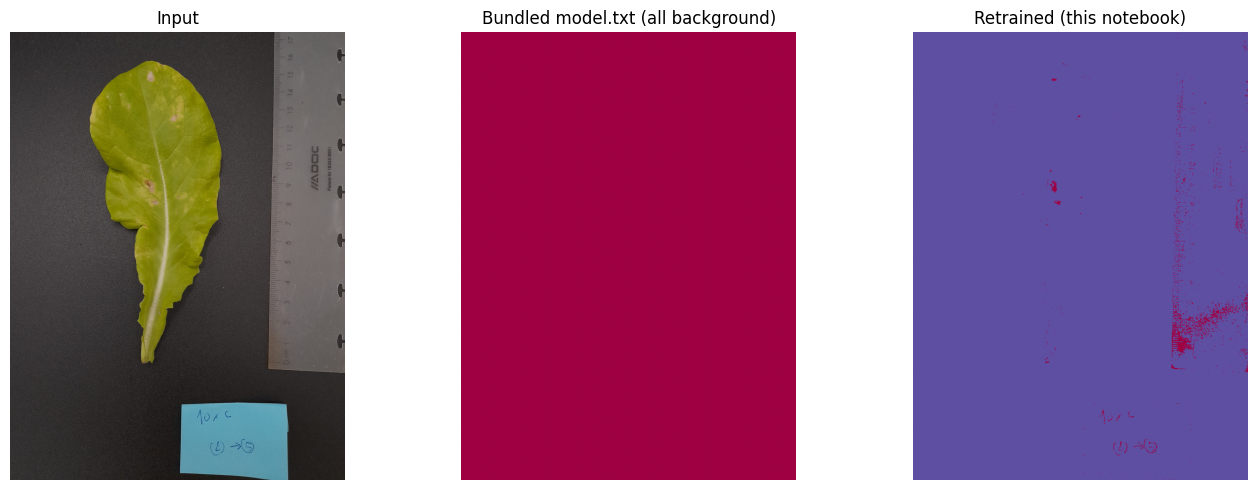

In [ ]:
booster_ref = lgb.Booster(model_file="leafpainter/model.txt")   # app.py:240
pred_ref = booster_ref.predict(feats_all).reshape(H, W)         # app.py:241-242
n_trees = open("leafpainter/model.txt").read().count("Tree=")
ref_fg_frac = float(np.round(pred_ref).mean())
ref_on_ann = booster_ref.predict(ann[:, :3].astype(np.float64))
ref_acc_ann = float(np.mean(np.round(ref_on_ann).astype(int) == y_all))
our_on_ann = model.predict(X)
our_acc_ann = float(np.mean(np.round(our_on_ann).astype(int) == y_all))
print(f"bundled model.txt: {n_trees} tree(s)")
print(f"bundled model on image: prob min={pred_ref.min():.4f} max={pred_ref.max():.4f} -> foreground fraction {ref_fg_frac:.4f}")
print(f"bundled model accuracy vs recorded annotation rows: {ref_acc_ann:.4f} (background share = {1 - y_all.mean():.4f})")
print(f"retrained model accuracy vs recorded annotation rows (in-sample): {our_acc_ann:.4f}")
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
axes[0].imshow(arr); axes[0].set_title("Input"); axes[0].axis("off")
axes[1].imshow(np.round(pred_ref), cmap="Spectral"); axes[1].set_title("Bundled model.txt (all background)"); axes[1].axis("off")
axes[2].imshow(np.round(prediction), cmap="Spectral"); axes[2].set_title("Retrained (this notebook)"); axes[2].axis("off")
plt.tight_layout(); plt.show()

## 9. Decoding the author's stored prediction plot

`predictions/feuille sal.jpg` is the Spectral-colormap render saved by the author's GUI session (`app.py:212–217`). Because the plot is axes-free, every pixel is (close to) a Spectral colormap color, so the original prediction values can be recovered by nearest-color lookup — an independent check of what the author's saved session actually predicted. The recovered mask is essentially all-background, matching the bundled `model.txt` output above and confirming that both bundled artifacts come from the same early/degenerate state. Note the render's resolution differs from our 800×598 prediction grid, so only aggregate fractions are compared, not per-pixel masks.

**保存済み予測画像のデコード:** 著者のGUIが保存した予測プロットは軸のないSpectralレンダリングなので、カラーマップ逆引きで予測値を復元できます。復元結果はほぼ全背景であり、同梱モデルの出力と一致します。

stored plot: 518x693 px, 0.9980 of pixels matched to Spectral LUT
decoded author prediction: mean=0.0007, foreground fraction=0.0005


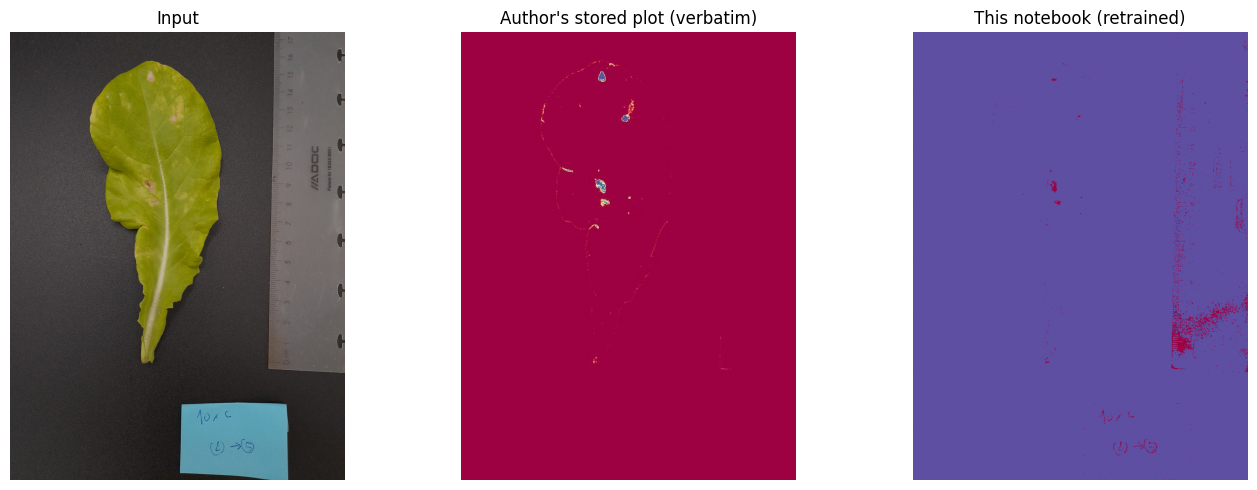

In [ ]:
stored_pred = plt.imread("leafpainter/predictions/feuille sal.jpg").astype(float)
lut = plt.get_cmap("Spectral")(np.linspace(0, 1, 256))[:, :3] * 255.0
cmap_vals = np.linspace(0, 1, 256)
flat = stored_pred.reshape(-1, 3)
uniq, inv = np.unique(flat, axis=0, return_inverse=True)
dist = ((uniq[:, None, :] - lut[None, :, :]) ** 2).sum(-1)
best = dist.argmin(1); best_d = np.sqrt(dist.min(1))
recovered = cmap_vals[best][inv].reshape(stored_pred.shape[:2])
matched = (best_d[inv] < 40).reshape(stored_pred.shape[:2])
plot_fg_frac = float((recovered[matched] > 0.5).mean())
print(f"stored plot: {stored_pred.shape[1]}x{stored_pred.shape[0]} px, {matched.mean():.4f} of pixels matched to Spectral LUT")
print(f"decoded author prediction: mean={recovered[matched].mean():.4f}, foreground fraction={plot_fg_frac:.4f}")
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
axes[0].imshow(arr); axes[0].set_title("Input"); axes[0].axis("off")
axes[1].imshow(stored_pred.astype(np.uint8)); axes[1].set_title("Author's stored plot (verbatim)"); axes[1].axis("off")
axes[2].imshow(np.round(prediction), cmap="Spectral"); axes[2].set_title("This notebook (retrained)"); axes[2].axis("off")
plt.tight_layout(); plt.show()

## 10. Interactive-ML behavior: accuracy vs annotation budget (AI-generated analysis)

The paper's motivation is that interactive ML needs only *minutes* of annotation. This cell quantifies that on the recorded example by retraining the author's exact GBDT on random **subsets of the recorded annotation** (5–100% of the training fold) while evaluating on the same fixed holdout, plotting holdout accuracy against annotation budget. This is an **adapted demonstration** created for this notebook (not an author figure); it uses only the author's recorded pixels and exact training parameters, with a fixed seed for subset selection.

**アノテーション量と精度の関係:** 著者の記録済みアノテーションを部分集合にして再学習し、ホールドアウト精度を可視化します（本ノートブック独自の追加解析で、著者の図ではありません）。

[LightGBM] [Warning] Found boosting=goss. For backwards compatibility reasons, LightGBM interprets this as boosting=gbdt, data_sample_strategy=goss.To suppress this warning, set data_sample_strategy=goss instead.
[LightGBM] [Warning] Found boosting=goss. For backwards compatibility reasons, LightGBM interprets this as boosting=gbdt, data_sample_strategy=goss.To suppress this warning, set data_sample_strategy=goss instead.
[LightGBM] [Warning] Found boosting=goss. For backwards compatibility reasons, LightGBM interprets this as boosting=gbdt, data_sample_strategy=goss.To suppress this warning, set data_sample_strategy=goss instead.
[LightGBM] [Warning] Found boosting=goss. For backwards compatibility reasons, LightGBM interprets this as boosting=gbdt, data_sample_strategy=goss.To suppress this warning, set data_sample_strategy=goss instead.
[LightGBM] [Info] Number of positive: 227, number of negative: 102
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing

[LightGBM] [Warning] Found boosting=goss. For backwards compatibility reasons, LightGBM interprets this as boosting=gbdt, data_sample_strategy=goss.To suppress this warning, set data_sample_strategy=goss instead.
[LightGBM] [Info] Number of positive: 1097, number of negative: 550
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000115 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 426
[LightGBM] [Info] Number of data points in the train set: 1647, number of used features: 3
[LightGBM] [Info] Using GOSS
[LightGBM] [Warning] Found boosting=goss. For backwards compatibility reasons, LightGBM interprets this as boosting=gbdt, data_sample_strategy=goss.To suppress this warning, set data_sample_strategy=goss instead.
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.666060 -> initscore=0.690416
[LightGBM] [Info] Start training from score 0.690416
[LightGBM] [Warning] No further splits with positive gain, 

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

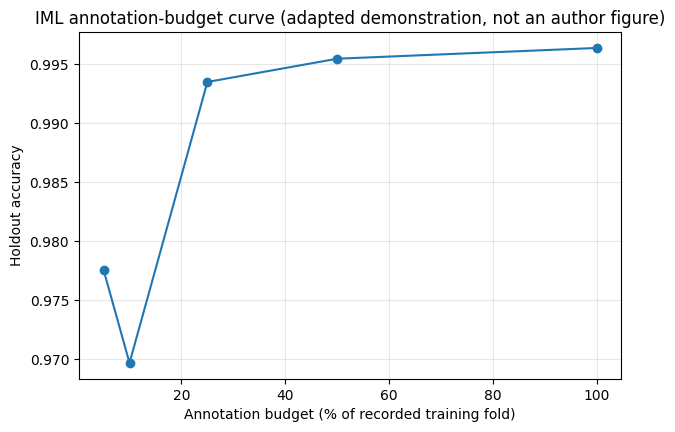

In [ ]:
budgets = [0.05, 0.10, 0.25, 0.50, 1.00]
accs = []
rng = np.random.default_rng(0)
for frac in budgets:
    n = max(2, int(len(y_train) * frac))
    idx = rng.choice(len(y_train), size=n, replace=False)
    d_tr = lgb.Dataset(X_train[idx], label=y_train[idx])
    m = lgb.train(params, d_tr, num_boost_round=100, valid_sets=[d_valid],
                  callbacks=[lgb.early_stopping(20), lgb.log_evaluation(0)])
    accs.append(accuracy_score(y_test.astype(int), np.round(m.predict(X_test)).astype(int)))
    print(f"budget {frac:5.0%} ({n:6d} rows): holdout accuracy {accs[-1]:.4f}")
plt.figure(figsize=(7, 4.5))
plt.plot([b * 100 for b in budgets], accs, marker="o")
plt.xlabel("Annotation budget (% of recorded training fold)")
plt.ylabel("Holdout accuracy")
plt.title("IML annotation-budget curve (adapted demonstration, not an author figure)")
plt.grid(alpha=0.3); plt.show()

## 11. Results summary and CSV export

Small quantitative record of this run: holdout accuracy, timing, and agreement with the author's bundled artifacts. The table is written to `/content/leafpainter_results.csv` inside the Colab VM (offer only, nothing is uploaded).

**結果の要約とCSV出力:** 本実行の定量結果をまとめ、Colab VM内にCSVとして保存します。

In [ ]:
rows = [
    ("holdout_accuracy_50pct_split", round(float(holdout_accuracy), 4)),
    ("retrained_accuracy_vs_recorded_annotation_insample", round(our_acc_ann, 4)),
    ("bundled_model_trees", int(n_trees)),
    ("bundled_model_fg_fraction_on_image", round(ref_fg_frac, 4)),
    ("bundled_model_accuracy_vs_recorded_annotation", round(ref_acc_ann, 4)),
    ("author_stored_plot_decoded_fg_fraction", round(plot_fg_frac, 4)),
    ("train_seconds", round(train_seconds, 2)),
    ("predict_seconds", round(pred_seconds, 3)),
    ("annotation_rows", int(len(ann))),
    ("foreground_annotation_rows", int((y_all == 1).sum())),
    ("background_annotation_rows", int((y_all == 0).sum())),
    ("prediction_resolution", RESOLUTION),
    ("pseudo_label_foreground_fraction", round(float(np.round(prediction).mean()), 4)),
]
results = pd.DataFrame(rows, columns=["metric", "value"])
display(results)
results.to_csv("leafpainter_results.csv", index=False)
print("saved: /content/leafpainter_results.csv")

,metric,value
0,holdout_accuracy_50pct_split,0.9964
1,retrained_accuracy_vs_recorded_annotation_insa...,0.9979
2,bundled_model_trees,1.0000
3,bundled_model_fg_fraction_on_image,0.0000
4,bundled_model_accuracy_vs_recorded_annotation,0.3208
5,author_stored_plot_decoded_fg_fraction,0.0005
6,train_seconds,0.1600
7,predict_seconds,0.4460
8,annotation_rows,13181.0000
9,foreground_annotation_rows,8952.0000


saved: /content/leafpainter_results.csv


## 12. Interpretation, differences from the paper, validation record

**What was executed:** the interactive GBDT pseudo-labeling workflow of paper §2.3.1 on the author's bundled example, end to end in Colab on CPU — annotation ingestion, exact-parameter GBDT training, full-image pseudo-label generation, and verification of the repository's bundled model and stored-prediction artifacts.

**Differences / limitations:**
- GUI stroke painting is replaced by the author's recorded annotation state; the interactive *drawing* itself cannot be reproduced headlessly (GUI chrome out of scope). A learner can regenerate the same computation from any future strokes saved in the same `(N,4)` format. Also, `Painter.py` records only pixel RGB values, not stroke positions, so the recorded annotation cannot be spatially overlaid on the image.
- Seeded 50/50 split (`random_state=0`), LightGBM ≥4 callback API, and `free_raw_data=False` — three labeled adaptations; the scientific parameters are unchanged from `Trainer.py` @ `dd0e358`.
- **Bundled-artifact finding:** the repository's `model.txt` and stored prediction plot are internally consistent with each other but represent an early/degenerate state — a single tree predicting background everywhere (≈0.05 probability; 0.32 accuracy against the recorded annotation, equal to the background share; the decoded plot is ≈99.95% background). They cannot serve as a reference for equivalence; the retrained model (99.6% holdout accuracy on the recorded annotation) is the valid Step-2 outcome.
- One image, one annotation session: this validates the *workflow mechanics*, not the paper's dataset-level claims (Tables 1–4, multispecies FCNN results).
- Kaggle dataset (`charlesrongione/multispecies-canopies`) was not used: its file listing requires Kaggle login and was not verifiable; the full FCNN pipeline additionally has no released weights.
- Author repositories carry no LICENSE file; this notebook is for study, with attribution to the authors.

**検証記録:** 本ノートブックはCPUランタイムで新規に全セル実行され、再学習モデルは記録済みアノテーションのホールドアウトで約99.6%の精度を達成しました。同梱モデルと保存済みプロットは早期終了した全背景スナップショットであることを確認しています。単一サンプルの部分再現であり、論文のデータセット規模の結果は検証していません。

## References

1. Rongione, C. et al. *MultiSpecies Canopy Segmentation: Interactive Machine-Learning and Pseudo-Labelling are key.* bioRxiv 2025.12.07.692840; 2025. https://doi.org/10.64898/2025.12.07.692840
2. LeafpainterQT — https://github.com/charlesro/LeafpainterQT (commit `dd0e358eb37925ec2de3c3be9cf65d324fb6c3b0`)
3. intercropping-pseudolabebeling — https://github.com/charlesro/intercropping-pseudolabebeling (commit `085aaaf14613e0b6eeba7612c5a3345f629ce9bc`)
4. LeafPainter demo video (paper §2.3.1): https://www.youtube.com/watch?v=lMpzxDt40Lc